In [1]:
from dendrocat import RadioSource
from astropy.io import fits
from spectral_cube import SpectralCube
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import sys
import importlib
from astropy.wcs import WCS
from scipy import interpolate
import pandas as pd
import sympy as syp
from astropy import units as u
import radio_beam
from astropy.table import Table
from radio_beam import Beam
from astropy import coordinates
from astropy import wcs
from astropy.nddata.utils import Cutout2D
from dendrocat.aperture import Ellipse
from regions import Regions, PixCoord
from astropy import stats
from itertools import chain
from radio_beam import Beams
from astropy.convolution import convolve
import Paths.Paths as paths
Path = paths.filepaths()



/home/t.yoo/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
from astropy.table import Table
import matplotlib as mpl
import astropy.constants as c
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from astropy.modeling.models import BlackBody
plt.rcParams['axes.labelsize']=25
plt.rcParams['xtick.labelsize']=25
plt.rcParams['ytick.labelsize']=25
plt.rcParams['axes.titlesize']=25
mpl.rcParams['axes.linewidth'] = 5
mpl.rcParams['xtick.major.size'] = 10
mpl.rcParams['xtick.major.width'] = 4
mpl.rcParams['xtick.minor.size'] = 5
mpl.rcParams['xtick.minor.width'] = 2
mpl.rcParams['ytick.major.size'] = 10
mpl.rcParams['ytick.major.width'] = 4
mpl.rcParams['ytick.minor.size'] = 5
mpl.rcParams['ytick.minor.width'] = 2
params = {"xtick.top": True, "ytick.right": True, "xtick.direction": "in", "ytick.direction": "in"}
plt.rcParams.update(params)


def get_noise(fitsfile, noiseregion):
    fitsdata = fits.open(b6data)
    image = fitsdata[0].data
    if len(image.shape)!=2:
        image = image[0][0] 
    hdrNB = fits.getheader(fitsfile)  
    wcsNB = WCS(hdrNB,naxis=2)
    container = []
    for reg in noiseregion:
        pix_reg = reg.to_pixel(wcsNB)
        noisemask = pix_reg.to_mask()
        noiseim = noisemask.cutout(image)
        container.append(noiseim.flatten())
    noiseim = list(chain.from_iterable(container))
    std = stats.mad_std(noiseim,ignore_nan=True)

    return std
def kappa(nu, nu0=271.1*u.GHz, kappa0=0.0114*u.cm**2*u.g**-1, beta=1.75):
    """
    Compute the opacity $\kappa$ given a reference frequency (or wavelength)
    and a power law governing the opacity as a fuction of frequency:
    $$ \kappa = \kappa_0 \left(\\frac{\\nu}{\\nu_0}\\right)^{\\beta} $$
    The default kappa=0.0114 at 271.1 GHz comes from extrapolating the
    Ossenkopf & Henning 1994 opacities for the thin-ice-mantle, 10^6 year model
    anchored at 1.0 mm with an assumed beta of 1.75.
    Parameters
    ----------
    nu: astropy.Quantity [u.spectral() equivalent]
        The frequency at which to evaluate kappa
    nu0: astropy.Quantity [u.spectral() equivalent]
        The reference frequency at which $\kappa$ is defined
    kappa0: astropy.Quantity [cm^2/g]
        The dust opacity per gram of H2 along the line of sight.  Because of
        the H2 conversion, this factor implicitly includes a dust to gas ratio
        (usually assumed 100)
    beta: float
        The power-law index governing kappa as a function of nu
    """
    return (kappa0*(nu.to(u.GHz,u.spectral())/nu0.to(u.GHz,u.spectral()))**(beta)).to(u.cm**2/u.g)
def get_S_thin(T_thin, surf_den_H_2, freq, r_thick,size):
    d = 5.41 * u.kpc
    radius = size * u.AU
    
    kappa_ = kappa(freq)
    
    avg_gas_mass = 2.8 * c.u
    surf_den = surf_den_H_2 * avg_gas_mass
    F_nu = np.pi * 2 * c.h * freq**3 / (c.c**2) * (np.e**(c.h*freq/(c.k_B*T_thin)) - 1)**(-1) * (1 - np.e**((-kappa_ * surf_den).to(u.dimensionless_unscaled)))
    
    S_nu_hole = (F_nu / np.pi) * ((np.pi * radius**2) - (np.pi * r_thick**2)) / d**2
    
    return S_nu_hole.to(u.mJy)

def thick_bb_emission(T, freq, radii):
    B_nu = (2 * freq**3 *c.h / (c.c**2) * 1 / (np.e**(c.h*freq/(c.k_B*T))-1)).to(u.W/u.m**2/u.Hz)
    d = 8.4 * u.kpc
    S_nu = B_nu * np.pi * radii**2 / d**2 
    
    return S_nu.to(u.mJy)

def total_emission(T_thin, T_thick, freq, surf_den, r_thick, r_total):
    flux = np.zeros((len(r_thick),len(surf_den)))
    for i,r in enumerate(r_thick):
        for j,den in enumerate(surf_den):
            flux[i,j] =  get_S_thin(T_thin, surf_den, freq, r_thick,r_total)+thick_bb_emission(T_thick, freq, r_thick)
    return flux
def get_bb_intensity(freq, surf_den,T_thin):
    
    kappa_ = kappa(freq)
    
    I_nu =  2 * c.h * freq**3 / (c.c**2) * (np.e**(c.h*freq/(c.k_B*T_thin)) - 1)**(-1) * (1 - np.e**((-kappa_ * surf_den).to(u.dimensionless_unscaled))) /u.sr
    
    
    
    return I_nu.to(u.Jy/u.arcsec**2)

def flux_gaussian_multiple_apertures(flux, major, minor, major_corr, minor_corr): # major, minor in sigma
    flux_rarr =flux * (1 - np.exp(-major_corr*minor_corr/2/major/minor))
    return flux_rarr

            
       
hdrNB6 = fits.getheader(Path.w51e_b6_tt0)  
my_beamNB6 = Beam.from_fits_header(hdrNB6)
hdrNB3 = fits.getheader(Path.w51e_b3_tt0)
my_beamNB3 = Beam.from_fits_header(hdrNB3)
wcsNB3 = WCS(hdrNB3,naxis=2)
wcsNB6 = WCS(hdrNB6,naxis=2)
r_max = np.sqrt(my_beamNB3.major/2*my_beamNB3.minor/2) * np.pi/180* 5.41*1000*206265
r_max = r_max.value
T_thin = 50 * u.K
T_thick = 50 * u.K
freq93 = 92.98 * u.GHz
freq225 = 226.69 * u.GHz

r_min = 1 # AU
#r_max = 713/2 # AU
r_thick = np.linspace(r_min, r_max, 1000) * u.AU
avg_gas_mass = 2.8 * c.u # from https://dust-emissivity.readthedocs.io/en/latest/api/dust_emissivity.blackbody.modified_blackbody.html
H_2_den_min = 1e+21 / u.cm**2
H_2_den_max = 1e+27 / u.cm**2
den_min = ((H_2_den_min  * avg_gas_mass).to(u.kg/u.m**2)).value
den_max = ((H_2_den_max * avg_gas_mass).to(u.kg/u.m**2)).value
surf_den = np.geomspace(den_min, den_max, 1000) * u.kg / u.m**2

b3flux_20 = get_bb_intensity(freq93, surf_den, 20*u.K)
b6flux_20 = get_bb_intensity(freq225, surf_den, 20*u.K)

b3flux_50 = get_bb_intensity(freq93, surf_den, 50*u.K)
b6flux_50 = get_bb_intensity(freq225, surf_den, 50*u.K)

b3flux_100 = get_bb_intensity(freq93, surf_den, 100*u.K)
b6flux_100 = get_bb_intensity(freq225, surf_den, 100*u.K)

b3flux_200 = get_bb_intensity(freq93, surf_den, 200*u.K)
b6flux_200 = get_bb_intensity(freq225, surf_den, 200*u.K)

b3flux_500 = get_bb_intensity(freq93, surf_den, 500*u.K)
b6flux_500 = get_bb_intensity(freq225, surf_den, 500*u.K)


"""
w51e_b3noise = get_noise(w51e_b3_tt0,w51e_b3_noiseregion)
w51e_b6noise = get_noise(w51e_b6,w51e_b3_noiseregion)
w51n_b3noise = get_noise(w51e_b3_tt0,w51e_b3_noiseregion)
w51n_b6noise = get_noise(w51e_b3_tt0,w51e_b3_noiseregion)
"""


w51e_catalog = Table.read(Path.w51e_dendro_matched_catalog_new) 
w51n_catalog = Table.read(Path.w51n_dendro_matched_catalog_new) 

w51e_peak_flux_b3 = w51e_catalog['flux_peak_b3']
w51e_peak_flux_b6 = w51e_catalog['flux_peak_b6']
w51n_peak_flux_b3 = w51n_catalog['flux_peak_b3']
w51n_peak_flux_b6 = w51n_catalog['flux_peak_b6']

w51e_b3_flux_fits = Table.read(Path.w51e_b3_flux)
w51e_b6_flux_fits = Table.read(Path.w51e_b6_flux)
w51n_b3_flux_fits = Table.read(Path.w51n_b3_flux)
w51n_b6_flux_fits = Table.read(Path.w51n_b6_flux)
print(Path.w51e_b3_flux)
w51e_b6_flux_conv_fits = Table.read(Path.w51e_b6_conv_flux)
w51n_b6_flux_conv_fits = Table.read(Path.w51n_b6_conv_flux)

w51e_b3_major = w51e_b3_flux_fits['deconvolved_major']
w51e_b6_major = w51e_b6_flux_conv_fits['deconvolved_major'] #FWHM, deg
w51n_b3_major = w51n_b3_flux_fits['deconvolved_major']
w51n_b6_major = w51n_b6_flux_conv_fits['deconvolved_major']
w51e_b3_minor = w51e_b3_flux_fits['deconvolved_minor']
w51e_b6_minor = w51e_b6_flux_conv_fits['deconvolved_minor']
w51n_b3_minor = w51n_b3_flux_fits['deconvolved_minor']
w51n_b6_minor = w51n_b6_flux_conv_fits['deconvolved_minor']


"""
w51e_b3_major_upperr = w51e_b3_flux_fits['deconvolved_major_upperr']
w51e_b6_major_upperr = w51e_b6_flux_fits['deconvolved_major_upperr']
w51n_b3_major_upperr = w51n_b3_flux_fits['deconvolved_major_upperr']
w51n_b6_major_upperr = w51n_b6_flux_fits['deconvolved_major_upperr']
w51e_b3_minor_upperr = w51e_b3_flux_fits['deconvolved_minor_upperr']
w51e_b6_minor_upperr = w51e_b6_flux_fits['deconvolved_minor_upperr']
w51n_b3_minor_upperr = w51n_b3_flux_fits['deconvolved_minor_upperr']
w51n_b6_minor_upperr = w51n_b6_flux_fits['deconvolved_minor_upperr']

w51e_b3_major_lowerr = w51e_b3_flux_fits['deconvolved_major_lowerr']
w51e_b6_major_lowerr = w51e_b6_flux_fits['deconvolved_major_lowerr']
w51n_b3_major_lowerr = w51n_b3_flux_fits['deconvolved_major_lowerr']
w51n_b6_major_lowerr = w51n_b6_flux_fits['deconvolved_major_lowerr']
w51e_b3_minor_lowerr = w51e_b3_flux_fits['deconvolved_minor_lowerr']
w51e_b6_minor_lowerr = w51e_b6_flux_fits['deconvolved_minor_lowerr']
w51n_b3_minor_lowerr = w51n_b3_flux_fits['deconvolved_minor_lowerr']
w51n_b6_minor_lowerr = w51n_b6_flux_fits['deconvolved_minor_lowerr']
"""
w51e_b3_int_flux = w51e_b3_flux_fits['flux']
w51e_b6_int_flux = w51e_b6_flux_conv_fits['flux']
w51n_b3_int_flux = w51n_b3_flux_fits['flux']
w51n_b6_int_flux = w51n_b6_flux_conv_fits['flux']
print(len(w51e_b3_int_flux))
print(len(w51e_b6_int_flux))
print(len(w51n_b3_int_flux))
print(len(w51n_b6_int_flux))

#w51e_b3_error_code = w51e_b3_flux_fits['error_code']
#w51e_b6_error_code  = w51e_b6_flux_conv_fits['error_code']
#w51n_b3_error_code  = w51n_b3_flux_fits['error_code']
#w51n_b6_error_code  = w51n_b6_flux_conv_fits['error_code']

scaleNB6 = wcsNB6.proj_plane_pixel_scales()[0]
scaleNB3 = wcsNB3.proj_plane_pixel_scales()[0]
sig_to_fwhm = np.sqrt(2*np.log(2))*2
#b6_min_size_maj =sig_to_fwhm*np.sqrt((my_beamNB6.major.value/scaleNB6.value/sig_to_fwhm+0.05)**2 
#                                 - (my_beamNB6.major.value/scaleNB6.value/sig_to_fwhm)**2)*scaleNB6.value
#b6_min_size_min =sig_to_fwhm*np.sqrt((my_beamNB6.minor.value/scaleNB6.value/sig_to_fwhm+0.05)**2 
#                                 - (my_beamNB6.minor.value/scaleNB6.value/sig_to_fwhm)**2)*scaleNB6.value

#b3_min_size_maj =sig_to_fwhm*np.sqrt((my_beamNB3.major.value/scaleNB3.value/sig_to_fwhm+0.05)**2 
#                                 - (my_beamNB3.major.value/scaleNB3.value/sig_to_fwhm)**2)*scaleNB3.value
#b3_min_size_min =sig_to_fwhm*np.sqrt((my_beamNB3.minor.value/scaleNB3.value/sig_to_fwhm+0.05)**2 
#                                 - (my_beamNB3.minor.value/scaleNB3.value/sig_to_fwhm)**2)*scaleNB3.value



w51e_b3_int_flux[w51e_b3_int_flux<0]=np.nan
w51n_b3_int_flux[w51n_b3_int_flux<0]=np.nan
w51e_b6_int_flux[w51e_b6_int_flux<0]=np.nan
w51n_b6_int_flux[w51n_b6_int_flux<0]=np.nan

w51e_b3_unresolved = np.logical_and(w51e_b3_major<=0, np.isfinite(w51e_b3_int_flux))
w51n_b3_unresolved = np.logical_and(w51n_b3_major<=0, np.isfinite(w51n_b3_int_flux))
w51e_b6_unresolved = np.logical_and(w51e_b6_major<=0, np.isfinite(w51e_b6_int_flux))
w51n_b6_unresolved = np.logical_and(w51n_b6_major<=0, np.isfinite(w51n_b6_int_flux))


w51e_b3_resolved = np.logical_and(w51e_b3_major>0, np.isfinite(w51e_b3_int_flux))
w51n_b3_resolved = np.logical_and(w51n_b3_major>0, np.isfinite(w51n_b3_int_flux))
w51e_b6_resolved = np.logical_and(w51e_b6_major>0, np.isfinite(w51e_b6_int_flux))
w51n_b6_resolved = np.logical_and(w51n_b6_major>0, np.isfinite(w51n_b6_int_flux))

w51e_b3_res_b6_res = np.logical_and(w51e_b3_resolved, w51e_b6_resolved)
w51n_b3_res_b6_res = np.logical_and(w51n_b3_resolved, w51n_b6_resolved)
w51e_b3_unres_b6_res = np.logical_and(w51e_b3_unresolved, w51e_b6_resolved)
w51n_b3_unres_b6_res = np.logical_and(w51n_b3_unresolved, w51n_b6_resolved)
w51e_b3_res_b6_unres = np.logical_and(w51e_b3_resolved, w51e_b6_unresolved)
w51n_b3_res_b6_unres = np.logical_and(w51n_b3_resolved, w51n_b6_unresolved)
w51e_b3_unres_b6_unres = np.logical_and(w51e_b3_unresolved, w51e_b6_unresolved)
w51n_b3_unres_b6_unres = np.logical_and(w51n_b3_unresolved, w51n_b6_unresolved)


w51e_b3_major[w51e_b3_major<=0]=np.nan
w51n_b3_major[w51n_b3_major<=0]=np.nan
w51e_b6_major[w51e_b6_major<=0]=np.nan
w51n_b6_major[w51n_b6_major<=0]=np.nan

w51e_b3_minor[w51e_b3_minor<=0]=np.nan
w51n_b3_minor[w51n_b3_minor<=0]=np.nan
w51e_b6_minor[w51e_b6_minor<=0]=np.nan
w51n_b6_minor[w51n_b6_minor<=0]=np.nan


w51e_b3_int_flux_err = w51e_b3_flux_fits['flux_err']
w51e_b6_int_flux_err = w51e_b6_flux_conv_fits['flux_err']
w51n_b3_int_flux_err = w51n_b3_flux_fits['flux_err']
w51n_b6_int_flux_err = w51n_b6_flux_conv_fits['flux_err']


"""
w51e_b3_int_upp_flux[w51e_b3_int_flux<0]=np.nan
w51e_b6_int_upp_flux[w51e_b6_int_flux<0]=np.nan
w51n_b3_int_upp_flux[w51n_b3_int_flux<0]=np.nan
w51n_b6_int_upp_flux[w51n_b6_int_flux<0]=np.nan

w51e_b3_int_low_flux[w51e_b3_int_flux<0]=np.nan
w51e_b6_int_low_flux[w51e_b6_int_flux<0]=np.nan
w51n_b3_int_low_flux[w51n_b3_int_flux<0]=np.nan
w51n_b6_int_low_flux[w51n_b6_int_flux<0]=np.nan
"""

w51e_b3_err = 2.065537678896079e-05
w51e_b6_err = 0.00012361802520203196
w51n_b3_err = 2.220660593897177e-05
w51n_b6_err = 8.95845803518789e-05


"""
w51e_b3_avg_size = np.sqrt(w51e_b3_major/2 * w51e_b3_minor/2) * np.pi/180 * 5.41*1000*206265
w51e_b6_avg_size = np.sqrt(w51e_b6_major/2 * w51e_b6_minor/2) * np.pi/180 * 5.41*1000*206265
w51n_b3_avg_size = np.sqrt(w51n_b3_major/2 * w51n_b3_minor/2) * np.pi/180 * 5.1*1000*206265
w51n_b6_avg_size = np.sqrt(w51n_b6_major/2 * w51n_b6_minor/2) * np.pi/180 * 5.1*1000*206265
"""
def arcsec_to_au(dist=5.41):
    #dist in kpc
    return 2 /2.355 * np.pi/180 * dist*1000*206265

    
#w51e_b3_avg_size = np.array([np.max((w51e_b3_major[i], w51e_b3_minor[i])) for i in range(len(w51e_b3_major.value))]) * arcsec_to_au() 
#w51e_b6_avg_size = np.array([np.max((w51e_b6_major[i], w51e_b6_minor[i])) for i in range(len(w51e_b6_major.value))]) * arcsec_to_au()
#w51n_b3_avg_size = np.array([np.max((w51n_b3_major[i], w51n_b3_minor[i])) for i in range(len(w51n_b3_major.value))]) * arcsec_to_au(dist=5.1)
#w51n_b6_avg_size = np.array([np.max((w51n_b6_major[i], w51n_b6_minor[i])) for i in range(len(w51n_b6_major.value))]) * arcsec_to_au(dist=5.1)

w51e_b3_avg_size_major = w51e_b3_major * arcsec_to_au()
w51e_b6_avg_size_major = w51e_b6_major * arcsec_to_au()
w51n_b3_avg_size_major = w51n_b3_major * arcsec_to_au()
w51n_b6_avg_size_major = w51n_b6_major * arcsec_to_au()

w51e_b3_avg_size_minor = w51e_b3_major * arcsec_to_au()
w51e_b6_avg_size_minor = w51e_b6_major * arcsec_to_au()
w51n_b3_avg_size_minor = w51n_b3_major * arcsec_to_au()
w51n_b6_avg_size_minor = w51n_b6_major * arcsec_to_au()


print(np.nanmin(w51e_b3_avg_size_major), np.nanmin(w51e_b6_avg_size_major), np.nanmin(w51n_b3_avg_size_major), np.nanmin(w51n_b6_avg_size_major))
print(np.nanmin(w51e_b3_avg_size_minor), np.nanmin(w51e_b6_avg_size_minor), np.nanmin(w51n_b3_avg_size_minor), np.nanmin(w51n_b6_avg_size_minor))
w51e_b3_avg_size_major[w51e_b3_unresolved] = np.nanmin(w51e_b3_avg_size_major)
w51e_b6_avg_size_major[w51e_b6_unresolved] = np.nanmin(w51e_b6_avg_size_major)
w51n_b3_avg_size_major[w51n_b3_unresolved] = np.nanmin(w51n_b3_avg_size_major)
w51n_b6_avg_size_major[w51n_b6_unresolved] = np.nanmin(w51n_b6_avg_size_major)

w51e_b3_avg_size_minor[w51e_b3_unresolved] = np.nanmin(w51e_b3_avg_size_minor)
w51e_b6_avg_size_minor[w51e_b6_unresolved] = np.nanmin(w51e_b6_avg_size_minor)
w51n_b3_avg_size_major[w51n_b3_unresolved] = np.nanmin(w51n_b3_avg_size_minor)
w51n_b6_avg_size_major[w51n_b6_unresolved] = np.nanmin(w51n_b6_avg_size_minor)

w51e_b3_major[w51e_b3_unresolved] = np.nanmin(w51e_b3_avg_size_major)/arcsec_to_au()
w51e_b6_major[w51e_b6_unresolved] = np.nanmin(w51e_b6_avg_size_major)/arcsec_to_au()
w51e_b3_minor[w51e_b3_unresolved] = np.nanmin(w51e_b3_avg_size_minor)/arcsec_to_au()
w51e_b6_minor[w51e_b6_unresolved] = np.nanmin(w51e_b6_avg_size_minor)/arcsec_to_au()

w51n_b3_major[w51n_b3_unresolved] = np.nanmin(w51n_b3_avg_size_major)/arcsec_to_au()
w51n_b6_major[w51n_b6_unresolved] = np.nanmin(w51n_b6_avg_size_major)/arcsec_to_au()
w51n_b3_minor[w51n_b3_unresolved] = np.nanmin(w51n_b3_avg_size_minor)/arcsec_to_au()
w51n_b6_minor[w51n_b6_unresolved] = np.nanmin(w51n_b6_avg_size_minor)/arcsec_to_au()

w51e_b3_flux_rescaled = w51e_b3_int_flux * (1-np.exp(-(2/2.355)**2*8*np.log(2)))                                      
w51e_b6_flux_rescaled = flux_gaussian_multiple_apertures(w51e_b6_int_flux, w51e_b3_major/np.sqrt(8*np.log(2)), w51e_b3_minor/np.sqrt(8*np.log(2)), 
                                                         w51e_b3_major*2/2.355, w51e_b3_minor*2/2.355)

w51n_b3_flux_rescaled = w51n_b3_int_flux * (1-np.exp(-(2/2.355)**2*8*np.log(2)))
w51n_b6_flux_rescaled = flux_gaussian_multiple_apertures(w51n_b6_int_flux, w51n_b3_major/np.sqrt(8*np.log(2)), w51n_b3_minor/np.sqrt(8*np.log(2)), 
                                                         w51n_b3_major*2/2.355, w51n_b3_minor*2/2.355)

w51e_b3_flux_err_rescaled = w51e_b3_int_flux_err * (1-np.exp(-(2/2.355)**2*8*np.log(2)))                                      
w51e_b6_flux_err_rescaled = flux_gaussian_multiple_apertures(w51e_b6_int_flux_err, w51e_b3_major/np.sqrt(8*np.log(2)), w51e_b3_minor/np.sqrt(8*np.log(2)), 
                                                         w51e_b3_major*2/2.355, w51e_b3_minor*2/2.355)
w51n_b3_flux_err_rescaled = w51n_b3_int_flux_err * (1-np.exp(-(2/2.355)**2*8*np.log(2)))
w51n_b6_flux_err_rescaled = flux_gaussian_multiple_apertures(w51n_b6_int_flux_err, w51n_b3_major/np.sqrt(8*np.log(2)), w51n_b3_minor/np.sqrt(8*np.log(2)), 
                                                         w51n_b3_major*2/2.355, w51n_b3_minor*2/2.355)

angular_size_in_sky_w51e_b3 = 2*w51e_b3_avg_size_major / 5400  * u.arcsec # au / pc -> arcsec, radius x 2
angular_size_in_sky_w51e_b6 = 2*w51e_b6_avg_size_major/ 5400* u.arcsec 
angular_size_in_sky_w51n_b3 = 2*w51n_b3_avg_size_major / 5400* u.arcsec 
angular_size_in_sky_w51n_b6 = 2*w51n_b6_avg_size_major / 5400* u.arcsec 



# keep same size (b3 size)
w51e_b3_flux_rescaled_int = w51e_b3_flux_rescaled / angular_size_in_sky_w51e_b3 **2  #Jy/arcsec**2
w51e_b6_flux_rescaled_int = w51e_b6_flux_rescaled / angular_size_in_sky_w51e_b6 **2
w51n_b3_flux_rescaled_int = w51n_b3_flux_rescaled / angular_size_in_sky_w51n_b3 **2
w51n_b6_flux_rescaled_int = w51n_b6_flux_rescaled / angular_size_in_sky_w51n_b6 **2


#print(w51e_b3_flux_rescaled.to(u.Jy), w51e_b6_flux_rescaled.to(u.Jy))
print('hoho',w51e_b3_flux_rescaled_int)


#print(w51n_b3_flux_rescaled_int, w51n_b6_flux_rescaled_int)

w51e_b3_flux_err_rescaled_int = w51e_b3_flux_err_rescaled / angular_size_in_sky_w51e_b3 **2
w51e_b6_flux_err_rescaled_int = w51e_b6_flux_err_rescaled / angular_size_in_sky_w51e_b6 **2
w51n_b3_flux_err_rescaled_int = w51n_b3_flux_err_rescaled / angular_size_in_sky_w51n_b3 **2
w51n_b6_flux_err_rescaled_int = w51n_b6_flux_err_rescaled / angular_size_in_sky_w51n_b6 **2

#w51e_snrind = np.where((w51e_peak_flux_b3>3*w51e_b3_err)&(w51e_peak_flux_b6>3*w51e_b6_err)&(w51e_b3_snr_major>3)&(w51e_b6_snr_major>3)&(w51e_b3_snr_minor>3)&(w51e_b6_snr_minor>3))[0]
#w51n_snrind = np.where((w51n_peak_flux_b3>3*w51n_b3_err)&(w51n_peak_flux_b6>3*w51n_b6_err)&(w51n_b3_snr_major>3)&(w51n_b6_snr_major>3)&(w51n_b3_snr_minor>3)&(w51n_b6_snr_minor>3))[0]
"""
for i in range(len(w51e_b3_major)):
    print(i, w51e_catalog['is_matched'][i],'%3.2e'%w51e_b3_flux_rescaled_int.value[i], '%3.2e'%w51e_b6_flux_rescaled_int.value[i], w51e_b3_avg_size[i], w51e_b6_avg_size[i], w51e_b3_error_code[i], w51e_b6_error_code[i])
for i in range(len(w51n_b3_major)):
    print(i, w51n_catalog['is_matched'][i],'%3.2e'%w51n_b3_flux_rescaled_int.value[i], '%3.2e'%w51n_b6_flux_rescaled_int.value[i], w51n_b3_avg_size[i], w51n_b6_avg_size[i], w51n_b3_error_code[i], w51n_b6_error_code[i])
"""   
    



/home/t.yoo/w51/w51_frag_new/flux/tables/w51e_b3.fits
118
118
93
93
273.9439074418752 304.67435409931244 230.7794298987154 320.95028792483896
273.9439074418752 304.67435409931244 230.7794298987154 320.95028792483896
hoho         flux        
         Jy         
--------------------
0.061383857078860356
                 ...
0.022767511773365043
0.022023619975175178
Length = 118 rows


"\nfor i in range(len(w51e_b3_major)):\n    print(i, w51e_catalog['is_matched'][i],'%3.2e'%w51e_b3_flux_rescaled_int.value[i], '%3.2e'%w51e_b6_flux_rescaled_int.value[i], w51e_b3_avg_size[i], w51e_b6_avg_size[i], w51e_b3_error_code[i], w51e_b6_error_code[i])\nfor i in range(len(w51n_b3_major)):\n    print(i, w51n_catalog['is_matched'][i],'%3.2e'%w51n_b3_flux_rescaled_int.value[i], '%3.2e'%w51n_b6_flux_rescaled_int.value[i], w51n_b3_avg_size[i], w51n_b6_avg_size[i], w51n_b3_error_code[i], w51n_b6_error_code[i])\n"

118 118 118


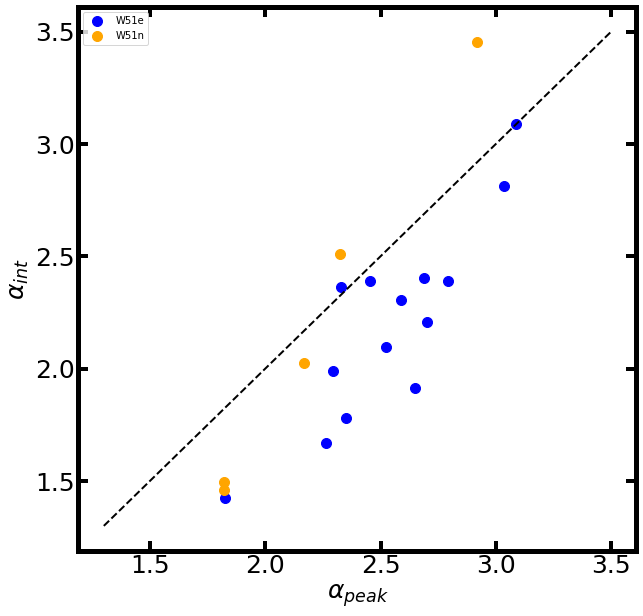

In [3]:
w51e_alpha_int = np.log10(w51e_b3_flux_rescaled_int/w51e_b6_flux_rescaled_int)/np.log10(freq93/freq225)
w51e_alpha = w51e_catalog['alpha']
w51n_alpha_int = np.log10(w51n_b3_flux_rescaled_int/w51n_b6_flux_rescaled_int)/np.log10(freq93/freq225)
w51n_alpha = w51n_catalog['alpha']
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111)
print(len(w51e_alpha_int), len(w51e_alpha), len(w51e_b3_res_b6_res))
ax.scatter(w51e_alpha[w51e_b3_res_b6_res], w51e_alpha_int[w51e_b3_res_b6_res], marker='o', s=100, c='blue', label='W51e')
ax.scatter(w51n_alpha[w51n_b3_res_b6_res], w51n_alpha_int[w51n_b3_res_b6_res], marker='o', s=100, c='orange', label='W51n')
ax.plot([1.3,3.5],[1.3,3.5], color='black', linestyle='--', linewidth=2)
ax.set_xlabel(r'$\alpha_{peak}$', fontsize=25)
ax.set_ylabel(r'$\alpha_{int}$', fontsize=25)
ax.legend()

In [4]:
def make_temp_hist2(b3flux, b6flux, surf_den, temparr, b3freq, b6freq, index, plot=False, ):
    # dist in pc
    temp_yso_arr = []
   
    for i in range(len(b3flux)):
        if i in index:
            if not np.isfinite(b3flux[i]):
                temp_yso_arr.append(np.nan)
                continue
            if not np.isfinite(b6flux[i]):
                temp_yso_arr.append(np.nan)
                continue
            
            b6fluxarr = []
            isinsidearr=[]

            for temp in temparr:
                b3flux_bb = get_bb_intensity(b3freq, surf_den, temp*u.K)
                b6flux_bb = get_bb_intensity(b6freq, surf_den, temp*u.K)
                b3ind = np.searchsorted(b3flux_bb.value, b3flux[i])
                if b3ind==len(surf_den):
                    b3ind = len(surf_den)-1
                    isinsidearr.append(False)
                else:
                    isinsidearr.append(True)
                b6flux_inbetween = b6flux_bb[b3ind].value
                b6fluxarr.append(b6flux_inbetween)


            tempind = np.searchsorted(b6fluxarr, b6flux[i])
            if tempind==len(b6fluxarr):
                tempind = len(b6fluxarr)-1
            if not isinsidearr[tempind]:
                temp_yso=np.nan
            else:
                if tempind>=len(b6fluxarr)-1:
                    weight=0
                else:
                    weight = (b6flux[i] - b6fluxarr[tempind])/(b6fluxarr[tempind+1] - b6fluxarr[tempind])

                temp_yso = temparr[tempind] + weight
        else:
            temp_yso = np.nan
            
        print(i, b3flux[i], b6flux[i], temp_yso) 
        temp_yso_arr.append(temp_yso)
    return np.array(temp_yso_arr)

In [5]:
temparr = np.arange(1,5000,step=1)

temp_yso_arr_w51e = make_temp_hist2(w51e_b3_flux_rescaled_int.value, w51e_b6_flux_rescaled_int.value, surf_den, temparr, freq93, freq225, np.arange(len(w51e_b3_flux_rescaled_int)))
temp_yso_arr_w51n = make_temp_hist2(w51n_b3_flux_rescaled_int.value, w51n_b6_flux_rescaled_int.value, surf_den, temparr, freq93, freq225, np.arange(len(w51n_b3_flux_rescaled_int)))



0 0.061383857078860356 0.43621747817625767 16.650242439499028


1 0.05433277976023189 0.14178412808193297 nan


2 0.1018595562317004 0.4508037431603409 nan


3 0.023173278393113755 0.3652710771992609 18.74711612388351


4 0.1899702558487702 1.7565301796944448 53.20947613648212


...

18 0.43327496570159113 0.7088096132632921 nan


19 0.38874010429212746 0.8142318742729362 nan


20 0.6017693829030539 0.857206409311826 nan


21 0.4244055490900954 1.554433338255997 nan


22 0.05211126164401778 0.11898776520262722 nan


[16.65024244         nan         nan 18.74711612 53.20947614 11.5970394
         nan         nan 58.0132205          nan         nan 23.04786546
         nan         nan 10.32617795 12.82175851 18.28869694  8.60450207
  9.2694701  24.30355756         nan         nan 17.41143352         nan
  5.65496381 24.45805942 40.85051525  5.04413615         nan         nan
 33.6047277  30.07618498         nan         nan  8.1991444  17.00844808
         nan 17.67476972 12.28352627         nan         nan  7.0735883
         nan         nan 12.43719812 13.48076162         nan  9.20715493
 38.06618452         nan         nan 12.17121824 13.93859095 14.11015253
 21.10307646         nan 28.28250065 30.31631075 20.68303958 23.92731761
 12.0686564          nan 10.09486033 40.3386572   8.74018949 11.20983525
         nan  9.39718486 16.4251605  18.66600773 10.34000731 20.5843767
 11.81142257         nan         nan         nan         nan         nan
         nan         nan         nan         nan      

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


...

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


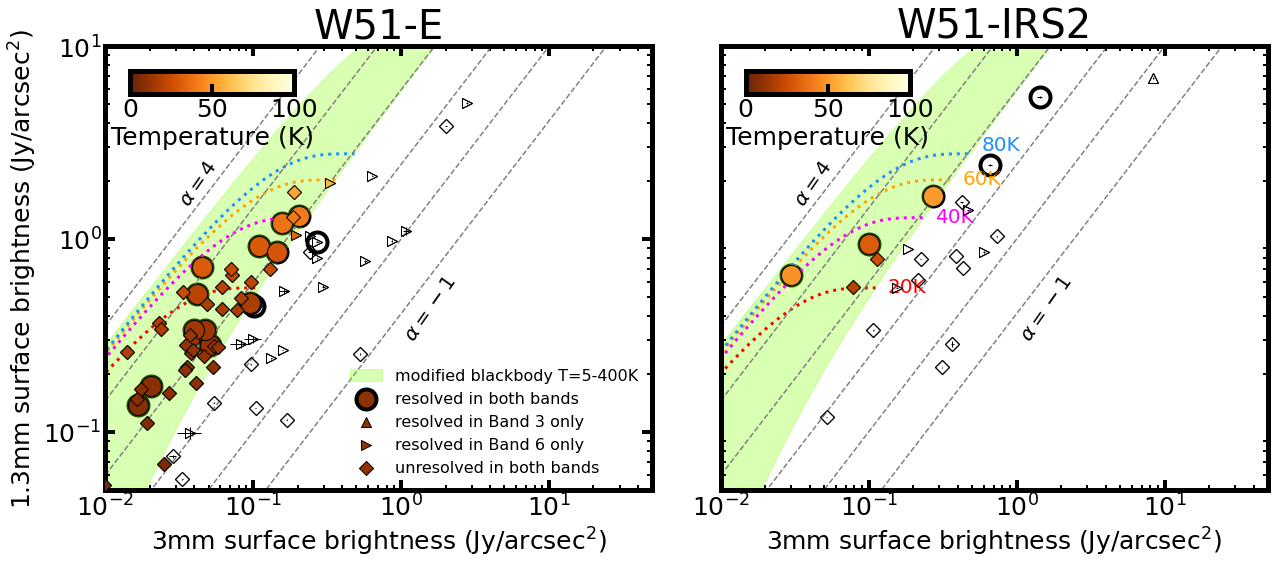

In [6]:
import seaborn as sns
import matplotlib
import matplotlib.cm as cm
from scipy.interpolate import CubicSpline

temp_yso_arr_w51e = np.array(temp_yso_arr_w51e)
temp_yso_arr_w51n = np.array(temp_yso_arr_w51n)
print(temp_yso_arr_w51e)
print(len(np.where(np.isfinite(temp_yso_arr_w51e))[0]), len(temp_yso_arr_w51e), len(temp_yso_arr_w51e)-56-len(np.where(np.isfinite(temp_yso_arr_w51e))[0]))
print(temp_yso_arr_w51n)
print(len(np.where(np.isfinite(temp_yso_arr_w51n))[0]), len(temp_yso_arr_w51n), len(temp_yso_arr_w51n)-50-len(np.where(np.isfinite(temp_yso_arr_w51n))[0]))

#temp_yso_arr_w51e[temp_yso_arr_w51e>500]=np.nan
#temp_yso_arr_w51n[temp_yso_arr_w51n>500]=np.nan

#nonan_w51e = np.where(np.isfinite(temp_yso_arr_w51e))
#nonan_w51n = np.where(np.isfinite(temp_yso_arr_w51n))

#nan_w51e = np.where(~np.isfinite(temp_yso_arr_w51e))
#nan_w51n = np.where(~np.isfinite(temp_yso_arr_w51n))


"""
w51e_b3_flux_rescaled_err_nonan = np.array(list(zip(w51e_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b3_flux_low_rescaled_int.to(u.Jy).value[nonan_w51e],
                                              w51e_b3_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51e])))
w51e_b3_flux_rescaled_err_nonan = np.array([[w51e_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b3_flux_low_rescaled_int.to(u.Jy).value[nonan_w51e]
                                             ,w51e_b3_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51e]]]).T

w51e_b6_flux_rescaled_err_nonan = np.array(list(zip(w51e_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b6_flux_low_rescaled_int.to(u.Jy).value[nonan_w51e],
                                              w51e_b6_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51e]))).T
w51e_b6_flux_rescaled_err_nonan = np.array([[w51e_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b6_flux_low_rescaled_int.to(u.Jy).value[nonan_w51e]
                                             ,w51e_b6_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51e]]]).T

w51n_b3_flux_rescaled_err_nonan = np.array(list(zip(w51n_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b3_flux_low_rescaled_int.to(u.Jy).value[nonan_w51n],
                                              w51n_b3_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51n]))).T
w51n_b3_flux_rescaled_err_nonan = np.array([[w51n_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b3_flux_low_rescaled_int.to(u.Jy).value[nonan_w51n]
                                             ,w51n_b3_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51n]]]).T
w51n_b6_flux_rescaled_err_nonan = np.array(list(zip(w51n_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b6_flux_low_rescaled_int.to(u.Jy).value[nonan_w51n],
                                              w51n_b6_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51n]))).T
w51n_b6_flux_rescaled_err_nonan = np.array([[w51n_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b6_flux_low_rescaled_int.to(u.Jy).value[nonan_w51n]
                                             ,w51n_b6_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51n]]]).T


w51e_b3_flux_rescaled_err_nan = np.array(list(zip(w51e_b3_flux_rescaled_int.to(u.Jy).value[nan_w51e]-w51e_b3_flux_low_rescaled_int.to(u.Jy).value[nan_w51e],
                                              w51e_b3_flux_upp_rescaled_int.to(u.Jy).value[nan_w51e]-w51e_b3_flux_rescaled_int.to(u.Jy).value[nan_w51e]))).T

w51e_b6_flux_rescaled_err_nan = np.array(list(zip(w51e_b6_flux_rescaled_int.to(u.Jy).value[nan_w51e]-w51e_b6_flux_low_rescaled_int.to(u.Jy).value[nan_w51e],
                                              w51e_b6_flux_upp_rescaled_int.to(u.Jy).value[nan_w51e]-w51e_b6_flux_rescaled_int.to(u.Jy).value[nan_w51e]))).T

w51n_b3_flux_rescaled_err_nan = np.array(list(zip(w51n_b3_flux_rescaled_int.to(u.Jy).value[nan_w51n]-w51n_b3_flux_low_rescaled_int.to(u.Jy).value[nan_w51n],
                                              w51n_b3_flux_upp_rescaled_int.to(u.Jy).value[nan_w51n]-w51n_b3_flux_rescaled_int.to(u.Jy).value[nan_w51n]))).T

w51n_b6_flux_rescaled_err_nan = np.array(list(zip(w51n_b6_flux_rescaled_int.to(u.Jy).value[nan_w51n]-w51n_b6_flux_low_rescaled_int.to(u.Jy).value[nan_w51n],
                                              w51n_b6_flux_upp_rescaled_int.to(u.Jy).value[nan_w51n]-w51n_b6_flux_rescaled_int.to(u.Jy).value[nan_w51n]))).T
"""
cmap = sns.color_palette("YlOrBr_r", as_cmap=True)
norm = matplotlib.colors.Normalize(vmin=0, vmax=100, clip=True)
mapper = cm.ScalarMappable(norm=norm, cmap=cmap)
color_w51e = np.array([(mapper.to_rgba(v)) for v in temp_yso_arr_w51e])
color_w51n = np.array([(mapper.to_rgba(v)) for v in temp_yso_arr_w51n])

fig = plt.figure(figsize=(19,8))
ax1 = fig.add_axes([0.1,0.15,0.4,0.77])
ax2 = fig.add_axes([0.55,0.15,0.4,0.77])

sc=ax1.scatter(w51e_b3_flux_rescaled_int.to(u.Jy).value, w51e_b6_flux_rescaled_int.to(u.Jy).value,s=0,
              c=temp_yso_arr_w51e,vmin=0,vmax=100,cmap=cmap)

def plot_flux_flux_temp(ax, b3flux, b6flux, b3fluxerr, b6fluxerr, color, idxlist, lws=[4,1,1,1],
                        label='W51-E', markerlist=['o','^', '>', 'D'], sizelist=[20,10,10,10], uplimarr=[False,True,True, True], lolimarr=[False,False,True,True]):
    for idx, marker, size, uplim, lolim, lw in zip(idxlist, markerlist, sizelist, uplimarr, lolimarr, lws):
        for x, y, xerr, yerr, c,  in zip(b3flux[idx], 
                                    b6flux[idx],
                                    b3fluxerr[idx],
                                    b6fluxerr[idx],
                                    color[idx], 
                                   ):
            ax.errorbar(x,y, 
                    xerr=xerr, 
                    yerr=yerr,
                    fmt=marker, c=c, 
                    ecolor='k', elinewidth=1, mec='k',ms=size,zorder=50)
            ax.scatter(x,y, edgecolor='k',lw=lw, marker=marker,zorder=0,s=size**2,c=c)

idxlist_w51e = [w51e_b3_res_b6_res, w51e_b3_res_b6_unres, w51e_b3_unres_b6_res , w51e_b3_unres_b6_unres   ]

plot_flux_flux_temp(ax1, w51e_b3_flux_rescaled_int.to(u.Jy).value, w51e_b6_flux_rescaled_int.to(u.Jy).value, 
                    w51e_b3_flux_err_rescaled_int, w51e_b3_flux_err_rescaled_int, color_w51e, idxlist_w51e,
                        label='W51-E',)
idxlist_w51n = [w51n_b3_res_b6_res, w51n_b3_res_b6_unres, w51n_b3_unres_b6_res , w51n_b3_unres_b6_unres   ]
    
plot_flux_flux_temp(ax2, w51n_b3_flux_rescaled_int.to(u.Jy).value, w51n_b6_flux_rescaled_int.to(u.Jy).value, 
                    w51n_b3_flux_err_rescaled_int, w51n_b3_flux_err_rescaled_int, color_w51n, idxlist_w51n,
                        label='W51-IRS2',)

axins1 = inset_axes(
    ax1,
    width="30%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="upper left", borderpad=2.5
    )
axins1.xaxis.set_ticks_position("bottom")
axcbr = fig.colorbar(sc, cax=axins1, orientation="horizontal", ticks=[0, 50, 100])
axcbr.set_label('Temperature (K)')
axins2 = inset_axes(
    ax2,
    width="30%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="upper left",borderpad=2.5
    )
axins2.xaxis.set_ticks_position("bottom")
axcbr = fig.colorbar(sc, cax=axins2, orientation="horizontal", ticks=[0, 50, 100])
axcbr.set_label('Temperature (K)')

"""
b3freq = 92982346121.91989 
b6freq = 226691598706.70853
spectral_indices=[-1,0,1,2,3,4]
for si in spectral_indices:
    ax1.plot([1e-5,1e-1],10**(np.log10([1e-5,1e-1]) - np.log10(b3freq/b6freq) * si), c='grey',ls='dashed')
ax1.text(1e-3,3e-2,r'$\alpha=4$',rotation=50,fontsize=14,c='gray')

ax1.text(1.5e-2,5e-3,r'$\alpha=-1$',rotation=50,fontsize=14,c='gray')
"""
b3flux_5 = get_bb_intensity(freq93, surf_den, 5*u.K)
b6flux_5 = get_bb_intensity(freq225, surf_den, 5*u.K)

b3flux_lowlimit_curve_over1 = get_bb_intensity(freq93, surf_den[-1], np.arange(2,400,1)*u.K)
b6flux_lowlimit_curve_over1 = get_bb_intensity(freq225, surf_den[-1], np.arange(2,400,1)*u.K)
b3flux_lowlimit_curve = np.concatenate((b3flux_5.value, b3flux_lowlimit_curve_over1.value))
b6flux_lowlimit_curve = np.concatenate((b6flux_5.value, b6flux_lowlimit_curve_over1.value))
b3flux_400 = get_bb_intensity(freq93, surf_den, 400*u.K)
b6flux_400 = get_bb_intensity(freq225, surf_den, 400*u.K)

interp = CubicSpline(b3flux_400.value, b6flux_400.value)

ax1.fill_between(b3flux_lowlimit_curve, b6flux_lowlimit_curve, interp(b3flux_lowlimit_curve), color='chartreuse', alpha=0.3,label='modified blackbody T=5-400K')
ax2.fill_between(b3flux_lowlimit_curve, b6flux_lowlimit_curve, interp(b3flux_lowlimit_curve), color='chartreuse', alpha=0.3)


b3flux_20 = get_bb_intensity(freq93, surf_den, 20*u.K)
b6flux_20 = get_bb_intensity(freq225, surf_den, 20*u.K)

b3flux_40 = get_bb_intensity(freq93, surf_den, 40*u.K)
b6flux_40 = get_bb_intensity(freq225, surf_den, 40*u.K)

b3flux_60 = get_bb_intensity(freq93, surf_den, 60*u.K)
b6flux_60 = get_bb_intensity(freq225, surf_den, 60*u.K)

b3flux_80 = get_bb_intensity(freq93, surf_den, 80*u.K)
b6flux_80 = get_bb_intensity(freq225, surf_den, 80*u.K)

ax1.plot(b3flux_20, b6flux_20, c='r', ls='dotted',lw=3)
ax1.plot(b3flux_40, b6flux_40, c='magenta', ls='dotted',lw=3)
ax1.plot(b3flux_60, b6flux_60, c='orange', ls='dotted',lw=3)
ax1.plot(b3flux_80, b6flux_80, c='dodgerblue', ls='dotted',lw=3)

ax2.plot(b3flux_20, b6flux_20, c='r', ls='dotted',lw=3)
ax2.plot(b3flux_40, b6flux_40, c='magenta', ls='dotted',lw=3)
ax2.plot(b3flux_60, b6flux_60, c='orange', ls='dotted',lw=3)
ax2.plot(b3flux_80, b6flux_80, c='dodgerblue', ls='dotted',lw=3)
ax2.text(1.2*b3flux_20[-1].value,0.95*b6flux_20[-1].value, '20K', fontsize=20,color='r')
ax2.text(1.2*b3flux_40[-1].value,0.95*b6flux_40[-1].value, '40K', fontsize=20,color='magenta')

ax2.text(1.2*b3flux_60[-1].value,0.95*b6flux_60[-1].value, '60K', fontsize=20,color='orange')
ax2.text(1.2*b3flux_80[-1].value,1.05*b6flux_80[-1].value, '80K', fontsize=20,color='dodgerblue')

#ax1.text(1.5e-3,7e-3,r'$T=100\,{\rm K}$',c='dodgerblue',fontsize=13)
#ax1.text(8e-4,3.5e-3,r'$T=50\,{\rm K}$',c='magenta',fontsize=13)
#ax1.text(3e-4,1e-3,r'$T=20\,{\rm K}$',c='r',fontsize=13)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('3mm surface brightness (Jy/arcsec$^2$)')
ax1.set_ylabel('1.3mm surface brightness (Jy/arcsec$^2$)')
#ax1.set_xlabel(r'$S_{\rm 3mm}$ $({\rm Jy\,arcsec^{-2}})$')
#ax1.set_ylabel(r'$S_{\rm 1.3mm, conv}$ $({\rm Jy\,arcsec^{-2}})$')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('3mm surface brightness (Jy/arcsec$^2$)')
#ax2.set_xlabel(r'$S_{\rm 3mm}$ $({\rm Jy\,arcsec^{-2}})$')
#ax2.set_ylabel(r'$S_{\rm int, 1.3mm}$ (Jy)')

ax1.set_title('W51-E', fontsize=40)
ax2.set_title('W51-IRS2', fontsize=40)
ax1.set_xlim(1e-2,5e1)
ax1.set_ylim(5e-2,1e1)
ax2.set_xlim(1e-2,5e1)
ax2.set_ylim(5e-2,1e1)

#ax1.set_xlim(1e9,1e13)
#ax1.set_ylim(1e10,5e12)
#ax2.set_xlim(1e9,1e13)
#ax2.set_ylim(1e10,5e12)
ax2.set_yticks([])
b3freq = 92982346121.91989 
b6freq = 226691598706.70853
spectral_indices=[-1,0,1,2,3,4]
for si in spectral_indices:
    ax1.plot([1e-2,1e2],10**(np.log10([1e-2,1e2]) - np.log10(b3freq/b6freq) * si), c='grey',ls='dashed')
    ax2.plot([1e-2,1e2],10**(np.log10([1e-2,1e2]) - np.log10(b3freq/b6freq) * si), c='grey',ls='dashed')

ax1.scatter([-1,-1],[-1,-1], c=mapper.to_rgba(10), s=20**2, lw=4, marker='o',label='resolved in both bands',edgecolor='k')
ax1.scatter([-1,-1],[-1,-1], c=mapper.to_rgba(10), s=10**2, lw=1, marker='^',label='resolved in Band 3 only',edgecolor='k') 
ax1.scatter([-1,-1],[-1,-1], c=mapper.to_rgba(10), s=10**2, lw=1, marker='>',label='resolved in Band 6 only',edgecolor='k') 
ax1.scatter([-1,-1],[-1,-1], c=mapper.to_rgba(10), s=10**2, lw=1, marker='D',label='unresolved in both bands',edgecolor='k') 

ax1.legend(fontsize=16, frameon=False, loc='lower right')
    
    

ax1.text(0.03,1.5,r'$\alpha=4$',rotation=55,fontsize=20)
ax1.text(1,0.3,r'$\alpha=-1$',rotation=55,fontsize=20)
ax2.text(0.03,1.5,r'$\alpha=4$',rotation=55,fontsize=20)
ax2.text(1,0.3,r'$\alpha=-1$',rotation=55,fontsize=20)
plt.savefig('fluxflux_temp.png')

18.97060606520148 29.995624535167043
18.97060606520148 29.995624535167043
16.42516049538332 28.72119415315597
39
118 47 93 6


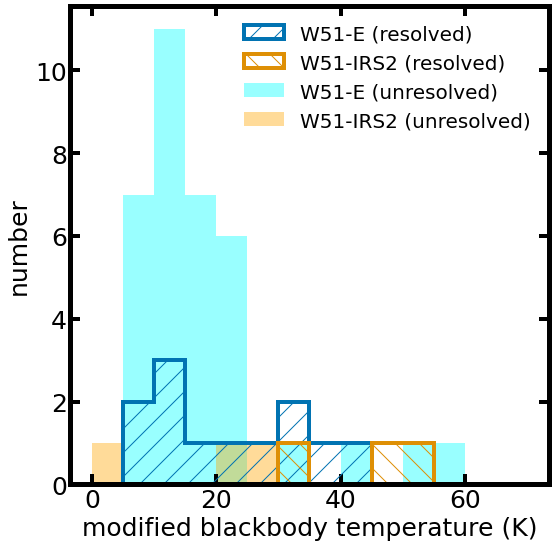

In [7]:
fig = plt.figure(figsize=(8,8))
ax3 = fig.add_axes([0.15,0.15,0.83,0.83])
tempbin = np.linspace(0,70,15)
ax3.hist(temp_yso_arr_w51e[w51e_b3_res_b6_res], bins=tempbin,  histtype='step', color=sns.color_palette('colorblind')[0], label='W51-E (resolved)',lw=4, hatch='/')
ax3.hist(temp_yso_arr_w51n[w51n_b3_res_b6_res], bins=tempbin,  histtype='step',color=sns.color_palette('colorblind')[1], label='W51-IRS2 (resolved)',hatch='\\',lw=4)

unresolveds_w51e = np.logical_or(np.logical_or(w51e_b3_res_b6_unres, w51e_b3_unres_b6_res), w51e_b3_unres_b6_unres)
unresolveds_w51n = np.logical_or(np.logical_or(w51n_b3_res_b6_unres, w51n_b3_unres_b6_res), w51n_b3_unres_b6_unres)
ax3.hist(temp_yso_arr_w51e[unresolveds_w51e], bins=tempbin,   facecolor='cyan', alpha=0.4,label='W51-E (unresolved)')
ax3.hist(temp_yso_arr_w51n[unresolveds_w51n], bins=tempbin,  facecolor='orange', alpha=0.4,label='W51-IRS2 (unresolved)')

print(np.nanmean(temp_yso_arr_w51e), np.nanmean(temp_yso_arr_w51n))
print(np.nanmean(temp_yso_arr_w51e), np.nanmean(temp_yso_arr_w51n))
print(np.nanmedian(temp_yso_arr_w51e), np.nanmedian(temp_yso_arr_w51n))

print(np.nanargmax(w51e_b3_flux_rescaled_int.to(u.Jy).value))
print(len(temp_yso_arr_w51e), len(np.where(np.isfinite(temp_yso_arr_w51e))[0]), len(temp_yso_arr_w51n),len(np.where(np.isfinite(temp_yso_arr_w51n))[0]))
ax3.legend(fontsize=20, frameon=False)
ax3.set_xlabel('modified blackbody temperature (K)')
ax3.set_ylabel('number')
#ax3.set_yticks([5,10,15])

plt.savefig('temp_hist.png')




*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


...

*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


*c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.


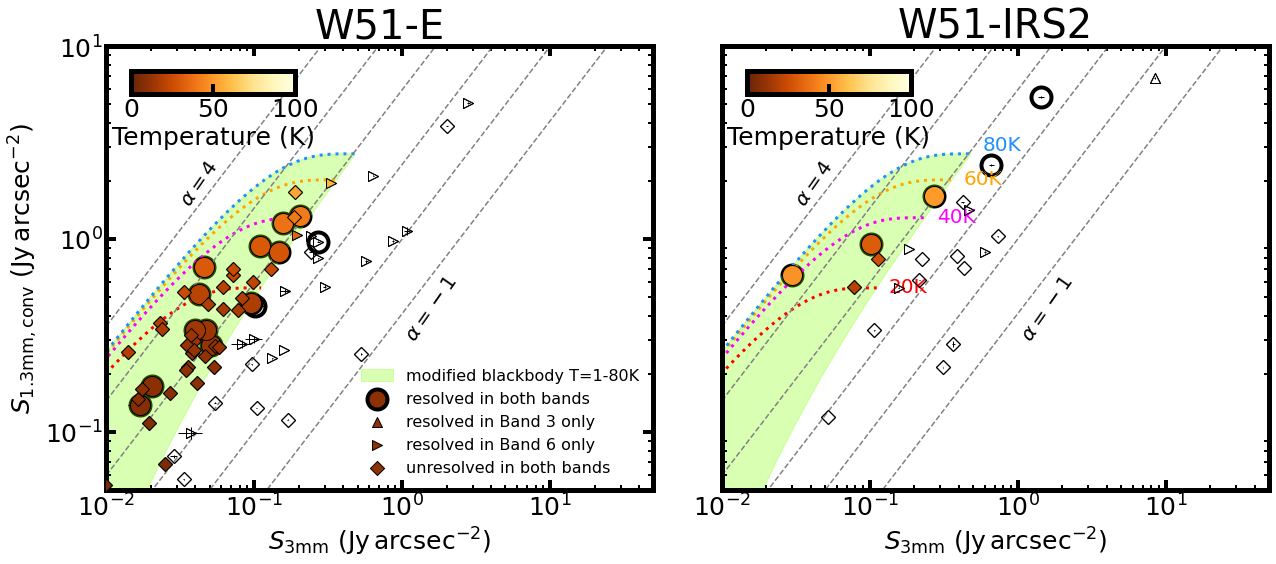

In [8]:
import seaborn as sns
import matplotlib
import matplotlib.cm as cm
from scipy.interpolate import CubicSpline

temp_yso_arr_w51e = np.array(temp_yso_arr_w51e)
temp_yso_arr_w51n = np.array(temp_yso_arr_w51n)
print(temp_yso_arr_w51e)
#temp_yso_arr_w51e[temp_yso_arr_w51e>500]=np.nan
#temp_yso_arr_w51n[temp_yso_arr_w51n>500]=np.nan

#nonan_w51e = np.where(np.isfinite(temp_yso_arr_w51e))
#nonan_w51n = np.where(np.isfinite(temp_yso_arr_w51n))

#nan_w51e = np.where(~np.isfinite(temp_yso_arr_w51e))
#nan_w51n = np.where(~np.isfinite(temp_yso_arr_w51n))


"""
w51e_b3_flux_rescaled_err_nonan = np.array(list(zip(w51e_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b3_flux_low_rescaled_int.to(u.Jy).value[nonan_w51e],
                                              w51e_b3_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51e])))
w51e_b3_flux_rescaled_err_nonan = np.array([[w51e_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b3_flux_low_rescaled_int.to(u.Jy).value[nonan_w51e]
                                             ,w51e_b3_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51e]]]).T

w51e_b6_flux_rescaled_err_nonan = np.array(list(zip(w51e_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b6_flux_low_rescaled_int.to(u.Jy).value[nonan_w51e],
                                              w51e_b6_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51e]))).T
w51e_b6_flux_rescaled_err_nonan = np.array([[w51e_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b6_flux_low_rescaled_int.to(u.Jy).value[nonan_w51e]
                                             ,w51e_b6_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51e]-w51e_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51e]]]).T

w51n_b3_flux_rescaled_err_nonan = np.array(list(zip(w51n_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b3_flux_low_rescaled_int.to(u.Jy).value[nonan_w51n],
                                              w51n_b3_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51n]))).T
w51n_b3_flux_rescaled_err_nonan = np.array([[w51n_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b3_flux_low_rescaled_int.to(u.Jy).value[nonan_w51n]
                                             ,w51n_b3_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b3_flux_rescaled_int.to(u.Jy).value[nonan_w51n]]]).T
w51n_b6_flux_rescaled_err_nonan = np.array(list(zip(w51n_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b6_flux_low_rescaled_int.to(u.Jy).value[nonan_w51n],
                                              w51n_b6_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51n]))).T
w51n_b6_flux_rescaled_err_nonan = np.array([[w51n_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b6_flux_low_rescaled_int.to(u.Jy).value[nonan_w51n]
                                             ,w51n_b6_flux_upp_rescaled_int.to(u.Jy).value[nonan_w51n]-w51n_b6_flux_rescaled_int.to(u.Jy).value[nonan_w51n]]]).T


w51e_b3_flux_rescaled_err_nan = np.array(list(zip(w51e_b3_flux_rescaled_int.to(u.Jy).value[nan_w51e]-w51e_b3_flux_low_rescaled_int.to(u.Jy).value[nan_w51e],
                                              w51e_b3_flux_upp_rescaled_int.to(u.Jy).value[nan_w51e]-w51e_b3_flux_rescaled_int.to(u.Jy).value[nan_w51e]))).T

w51e_b6_flux_rescaled_err_nan = np.array(list(zip(w51e_b6_flux_rescaled_int.to(u.Jy).value[nan_w51e]-w51e_b6_flux_low_rescaled_int.to(u.Jy).value[nan_w51e],
                                              w51e_b6_flux_upp_rescaled_int.to(u.Jy).value[nan_w51e]-w51e_b6_flux_rescaled_int.to(u.Jy).value[nan_w51e]))).T

w51n_b3_flux_rescaled_err_nan = np.array(list(zip(w51n_b3_flux_rescaled_int.to(u.Jy).value[nan_w51n]-w51n_b3_flux_low_rescaled_int.to(u.Jy).value[nan_w51n],
                                              w51n_b3_flux_upp_rescaled_int.to(u.Jy).value[nan_w51n]-w51n_b3_flux_rescaled_int.to(u.Jy).value[nan_w51n]))).T

w51n_b6_flux_rescaled_err_nan = np.array(list(zip(w51n_b6_flux_rescaled_int.to(u.Jy).value[nan_w51n]-w51n_b6_flux_low_rescaled_int.to(u.Jy).value[nan_w51n],
                                              w51n_b6_flux_upp_rescaled_int.to(u.Jy).value[nan_w51n]-w51n_b6_flux_rescaled_int.to(u.Jy).value[nan_w51n]))).T
"""
cmap = sns.color_palette("YlOrBr_r", as_cmap=True)
norm = matplotlib.colors.Normalize(vmin=0, vmax=100, clip=True)
mapper = cm.ScalarMappable(norm=norm, cmap=cmap)
color_w51e = np.array([(mapper.to_rgba(v)) for v in temp_yso_arr_w51e])
color_w51n = np.array([(mapper.to_rgba(v)) for v in temp_yso_arr_w51n])

fig = plt.figure(figsize=(19,8))
ax1 = fig.add_axes([0.1,0.15,0.4,0.77])
ax2 = fig.add_axes([0.55,0.15,0.4,0.77])

sc=ax1.scatter(w51e_b3_flux_rescaled_int.to(u.Jy).value, w51e_b6_flux_rescaled_int.to(u.Jy).value,s=0,
              c=temp_yso_arr_w51e,vmin=0,vmax=100,cmap=cmap)

def plot_flux_flux_temp(ax, b3flux, b6flux, b3fluxerr, b6fluxerr, color, idxlist, lws=[4,1,1,1],
                        label='W51-E', markerlist=['o','^', '>', 'D'], sizelist=[20,10,10,10], uplimarr=[False,True,True, True], lolimarr=[False,False,True,True]):
    for idx, marker, size, uplim, lolim, lw in zip(idxlist, markerlist, sizelist, uplimarr, lolimarr, lws):
        for x, y, xerr, yerr, c,  in zip(b3flux[idx], 
                                    b6flux[idx],
                                    b3fluxerr[idx],
                                    b6fluxerr[idx],
                                    color[idx], 
                                   ):
            ax.errorbar(x,y, 
                    xerr=xerr, 
                    yerr=yerr,
                    fmt=marker, c=c, 
                    ecolor='k', elinewidth=1, mec='k',ms=size,zorder=50)
            ax.scatter(x,y, edgecolor='k',lw=lw, marker=marker,zorder=0,s=size**2,c=c)

idxlist_w51e = [w51e_b3_res_b6_res, w51e_b3_res_b6_unres, w51e_b3_unres_b6_res , w51e_b3_unres_b6_unres   ]

plot_flux_flux_temp(ax1, w51e_b3_flux_rescaled_int.to(u.Jy).value, w51e_b6_flux_rescaled_int.to(u.Jy).value, 
                    w51e_b3_flux_err_rescaled_int, w51e_b3_flux_err_rescaled_int, color_w51e, idxlist_w51e,
                        label='W51-E',)
idxlist_w51n = [w51n_b3_res_b6_res, w51n_b3_res_b6_unres, w51n_b3_unres_b6_res , w51n_b3_unres_b6_unres   ]
    
plot_flux_flux_temp(ax2, w51n_b3_flux_rescaled_int.to(u.Jy).value, w51n_b6_flux_rescaled_int.to(u.Jy).value, 
                    w51n_b3_flux_err_rescaled_int, w51n_b3_flux_err_rescaled_int, color_w51n, idxlist_w51n,
                        label='W51-IRS2',)

axins1 = inset_axes(
    ax1,
    width="30%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="upper left", borderpad=2.5
    )
axins1.xaxis.set_ticks_position("bottom")
axcbr = fig.colorbar(sc, cax=axins1, orientation="horizontal", ticks=[0, 50, 100])
axcbr.set_label('Temperature (K)')
axins2 = inset_axes(
    ax2,
    width="30%",  # width: 50% of parent_bbox width
    height="5%",  # height: 5%
    loc="upper left",borderpad=2.5
    )
axins2.xaxis.set_ticks_position("bottom")
axcbr = fig.colorbar(sc, cax=axins2, orientation="horizontal", ticks=[0, 50, 100])
axcbr.set_label('Temperature (K)')

"""
b3freq = 92982346121.91989 
b6freq = 226691598706.70853
spectral_indices=[-1,0,1,2,3,4]
for si in spectral_indices:
    ax1.plot([1e-5,1e-1],10**(np.log10([1e-5,1e-1]) - np.log10(b3freq/b6freq) * si), c='grey',ls='dashed')
ax1.text(1e-3,3e-2,r'$\alpha=4$',rotation=50,fontsize=14,c='gray')

ax1.text(1.5e-2,5e-3,r'$\alpha=-1$',rotation=50,fontsize=14,c='gray')
"""
b3flux_1 = get_bb_intensity(freq93, surf_den, 1*u.K)
b6flux_1 = get_bb_intensity(freq225, surf_den, 1*u.K)

b3flux_lowlimit_curve_over1 = get_bb_intensity(freq93, surf_den[-1], np.arange(2,80,1)*u.K)
b6flux_lowlimit_curve_over1 = get_bb_intensity(freq225, surf_den[-1], np.arange(2,80,1)*u.K)
b3flux_lowlimit_curve = np.concatenate((b3flux_1.value, b3flux_lowlimit_curve_over1.value))
b6flux_lowlimit_curve = np.concatenate((b6flux_1.value, b6flux_lowlimit_curve_over1.value))
b3flux_80 = get_bb_intensity(freq93, surf_den, 80*u.K)
b6flux_80 = get_bb_intensity(freq225, surf_den, 80*u.K)

interp = CubicSpline(b3flux_80.value, b6flux_80.value)

ax1.fill_between(b3flux_lowlimit_curve, b6flux_lowlimit_curve, interp(b3flux_lowlimit_curve), color='chartreuse', alpha=0.3,label='modified blackbody T=1-80K')
ax2.fill_between(b3flux_lowlimit_curve, b6flux_lowlimit_curve, interp(b3flux_lowlimit_curve), color='chartreuse', alpha=0.3)


b3flux_20 = get_bb_intensity(freq93, surf_den, 20*u.K)
b6flux_20 = get_bb_intensity(freq225, surf_den, 20*u.K)

b3flux_40 = get_bb_intensity(freq93, surf_den, 40*u.K)
b6flux_40 = get_bb_intensity(freq225, surf_den, 40*u.K)

b3flux_60 = get_bb_intensity(freq93, surf_den, 60*u.K)
b6flux_60 = get_bb_intensity(freq225, surf_den, 60*u.K)

b3flux_80 = get_bb_intensity(freq93, surf_den, 80*u.K)
b6flux_80 = get_bb_intensity(freq225, surf_den, 80*u.K)

ax1.plot(b3flux_20, b6flux_20, c='r', ls='dotted',lw=3)
ax1.plot(b3flux_40, b6flux_40, c='magenta', ls='dotted',lw=3)
ax1.plot(b3flux_60, b6flux_60, c='orange', ls='dotted',lw=3)
ax1.plot(b3flux_80, b6flux_80, c='dodgerblue', ls='dotted',lw=3)

ax2.plot(b3flux_20, b6flux_20, c='r', ls='dotted',lw=3)
ax2.plot(b3flux_40, b6flux_40, c='magenta', ls='dotted',lw=3)
ax2.plot(b3flux_60, b6flux_60, c='orange', ls='dotted',lw=3)
ax2.plot(b3flux_80, b6flux_80, c='dodgerblue', ls='dotted',lw=3)
ax2.text(1.2*b3flux_20[-1].value,0.95*b6flux_20[-1].value, '20K', fontsize=20,color='r')
ax2.text(1.2*b3flux_40[-1].value,0.95*b6flux_40[-1].value, '40K', fontsize=20,color='magenta')

ax2.text(1.2*b3flux_60[-1].value,0.95*b6flux_60[-1].value, '60K', fontsize=20,color='orange')
ax2.text(1.2*b3flux_80[-1].value,1.05*b6flux_80[-1].value, '80K', fontsize=20,color='dodgerblue')

#ax1.text(1.5e-3,7e-3,r'$T=100\,{\rm K}$',c='dodgerblue',fontsize=13)
#ax1.text(8e-4,3.5e-3,r'$T=50\,{\rm K}$',c='magenta',fontsize=13)
#ax1.text(3e-4,1e-3,r'$T=20\,{\rm K}$',c='r',fontsize=13)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel(r'$S_{\rm 3mm}$ $({\rm Jy\,arcsec^{-2}})$')
ax1.set_ylabel(r'$S_{\rm 1.3mm, conv}$ $({\rm Jy\,arcsec^{-2}})$')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel(r'$S_{\rm 3mm}$ $({\rm Jy\,arcsec^{-2}})$')
#ax2.set_ylabel(r'$S_{\rm int, 1.3mm}$ (Jy)')

ax1.set_title('W51-E', fontsize=40)
ax2.set_title('W51-IRS2', fontsize=40)
ax1.set_xlim(1e-2,5e1)
ax1.set_ylim(5e-2,1e1)
ax2.set_xlim(1e-2,5e1)
ax2.set_ylim(5e-2,1e1)

#ax1.set_xlim(1e9,1e13)
#ax1.set_ylim(1e10,5e12)
#ax2.set_xlim(1e9,1e13)
#ax2.set_ylim(1e10,5e12)
ax2.set_yticks([])
b3freq = 92982346121.91989 
b6freq = 226691598706.70853
spectral_indices=[-1,0,1,2,3,4]
for si in spectral_indices:
    ax1.plot([1e-2,1e2],10**(np.log10([1e-2,1e2]) - np.log10(b3freq/b6freq) * si), c='grey',ls='dashed')
    ax2.plot([1e-2,1e2],10**(np.log10([1e-2,1e2]) - np.log10(b3freq/b6freq) * si), c='grey',ls='dashed')

ax1.scatter([-1,-1],[-1,-1], c=mapper.to_rgba(10), s=20**2, lw=4, marker='o',label='resolved in both bands',edgecolor='k')
ax1.scatter([-1,-1],[-1,-1], c=mapper.to_rgba(10), s=10**2, lw=1, marker='^',label='resolved in Band 3 only',edgecolor='k') 
ax1.scatter([-1,-1],[-1,-1], c=mapper.to_rgba(10), s=10**2, lw=1, marker='>',label='resolved in Band 6 only',edgecolor='k') 
ax1.scatter([-1,-1],[-1,-1], c=mapper.to_rgba(10), s=10**2, lw=1, marker='D',label='unresolved in both bands',edgecolor='k') 

ax1.legend(fontsize=16, frameon=False, loc='lower right')
    
    

ax1.text(0.03,1.5,r'$\alpha=4$',rotation=55,fontsize=20)
ax1.text(1,0.3,r'$\alpha=-1$',rotation=55,fontsize=20)
ax2.text(0.03,1.5,r'$\alpha=4$',rotation=55,fontsize=20)
ax2.text(1,0.3,r'$\alpha=-1$',rotation=55,fontsize=20)
plt.savefig('fluxflux_temp.png')

18.97060606520148 29.995624535167043
18.97060606520148 29.995624535167043
16.42516049538332 28.72119415315597
39
118 47 93 6


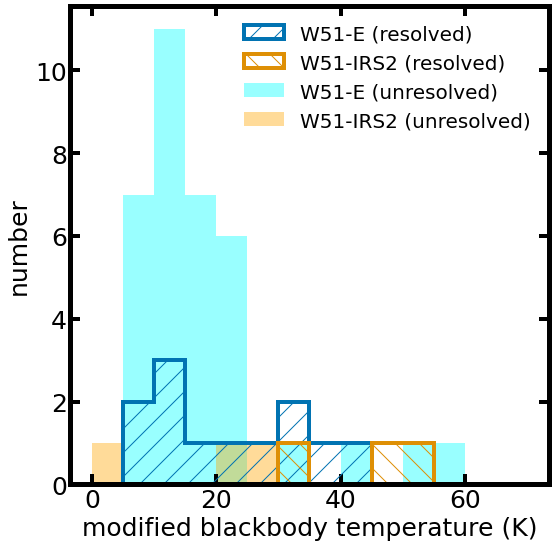

In [9]:
fig = plt.figure(figsize=(8,8))
ax3 = fig.add_axes([0.15,0.15,0.83,0.83])
tempbin = np.linspace(0,70,15)
ax3.hist(temp_yso_arr_w51e[w51e_b3_res_b6_res], bins=tempbin,  histtype='step', color=sns.color_palette('colorblind')[0], label='W51-E (resolved)',lw=4, hatch='/')
ax3.hist(temp_yso_arr_w51n[w51n_b3_res_b6_res], bins=tempbin,  histtype='step',color=sns.color_palette('colorblind')[1], label='W51-IRS2 (resolved)',hatch='\\',lw=4)

unresolveds_w51e = np.logical_or(np.logical_or(w51e_b3_res_b6_unres, w51e_b3_unres_b6_res), w51e_b3_unres_b6_unres)
unresolveds_w51n = np.logical_or(np.logical_or(w51n_b3_res_b6_unres, w51n_b3_unres_b6_res), w51n_b3_unres_b6_unres)
ax3.hist(temp_yso_arr_w51e[unresolveds_w51e], bins=tempbin,   facecolor='cyan', alpha=0.4,label='W51-E (unresolved)')
ax3.hist(temp_yso_arr_w51n[unresolveds_w51n], bins=tempbin,  facecolor='orange', alpha=0.4,label='W51-IRS2 (unresolved)')

print(np.nanmean(temp_yso_arr_w51e), np.nanmean(temp_yso_arr_w51n))
print(np.nanmean(temp_yso_arr_w51e), np.nanmean(temp_yso_arr_w51n))
print(np.nanmedian(temp_yso_arr_w51e), np.nanmedian(temp_yso_arr_w51n))

print(np.nanargmax(w51e_b3_flux_rescaled_int.to(u.Jy).value))
print(len(temp_yso_arr_w51e), len(np.where(np.isfinite(temp_yso_arr_w51e))[0]), len(temp_yso_arr_w51n),len(np.where(np.isfinite(temp_yso_arr_w51n))[0]))
ax3.legend(fontsize=20, frameon=False)
ax3.set_xlabel('modified blackbody temperature (K)')
ax3.set_ylabel('number')
#ax3.set_yticks([5,10,15])

plt.savefig('temp_hist.png')

In [10]:
w51e_catalog['temp']=temp_yso_arr_w51e
w51n_catalog['temp']=temp_yso_arr_w51n
w51e_catalog.write(Path.w51e_dendro_matched_catalog_new,overwrite=True, format='fits')
w51n_catalog.write(Path.w51n_dendro_matched_catalog_new,overwrite=True, format='fits')